# 🧪 Análisis de datos para la transformación productiva de un emprendimiento de bienestar

### Proyecto Final — Inteligencia Artificial · Nivel Explorador (TalentoTech)

**Caso de estudio:** optimización de un emprendimiento de productos de bienestar (Fuxion)
a partir del análisis de sus pedidos, inventario y afiliaciones.

**Línea temática:** *transformación productiva mediante ciencia y tecnología.*

---
Este notebook ilustra las **primeras fases del ciclo de vida de un proyecto de Machine Learning**:
la detección del problema, la identificación de los datos y *stakeholders*, y el
**análisis exploratorio de datos (EDA)**.


## 1. 📚 Introducción teórica: el ciclo de vida de un proyecto de ML

Un proyecto de *Machine Learning* (ML) no comienza programando modelos: comienza
**entendiendo el problema y los datos**. Una de las metodologías más usadas para
estructurar este ciclo de vida es **CRISP-DM** (*Cross Industry Standard Process for
Data Mining*), que organiza el trabajo en seis fases:

| Fase | Descripción | ¿En este proyecto? |
|------|-------------|--------------------|
| 1. **Comprensión del negocio** | Definir el problema y los objetivos. | ✅ Secciones 2 y 3 |
| 2. **Comprensión de los datos** | Recolectar y explorar los datos disponibles. | ✅ Secciones 4 y 5 |
| 3. **Preparación de los datos** | Limpiar, transformar y normalizar. | ✅ Secciones 6 a 9 |
| 4. **Modelado** | Entrenar algoritmos de ML. | 🔜 Fases posteriores |
| 5. **Evaluación** | Medir el desempeño del modelo. | 🔜 Fases posteriores |
| 6. **Despliegue** | Poner el modelo en producción. | 🔜 Fases posteriores |

> 🎯 **Alcance de este trabajo (Nivel Explorador):** las fases **1, 2 y 3**. El objetivo
> no es predecir todavía, sino **conocer profundamente el negocio y sus datos** para
> tomar decisiones informadas y dejar la base lista para un futuro modelo predictivo.

El **análisis exploratorio de datos (EDA)** es el componente central de estas fases:
mediante estadística descriptiva y visualización, busca **patrones, tendencias,
relaciones y anomalías** que orienten las decisiones.


## 2. 🎯 Selección del contexto y problema específico

**Contexto.** El caso de estudio es un emprendimiento real de **distribución de
productos de bienestar y nutrición** (marca Fuxion). El negocio combina varias
fuentes de ingreso: la **reventa de productos** (margen sobre el precio de catálogo),
la **comisión por venta directa**, la **comisión por afiliación** de nuevas personas a
la red, y la **venta de inventario** (stock) en distintas ciudades.

**Problema detectado.** El emprendimiento toma decisiones de **compra de inventario,
precios, enfoque geográfico y crecimiento de la red** de forma intuitiva, sin
apoyarse en sus propios datos históricos. Esto genera riesgos concretos:

- 📦 **Capital inmovilizado** en inventario que rota lento o **se vence** antes de venderse.
- 🛒 Desconocimiento de **qué productos y ciudades** generan realmente más margen.
- 📈 Falta de visibilidad sobre la **estacionalidad** y la evolución del negocio.

> ❓ **Pregunta de negocio:** *¿Qué productos, ciudades y momentos concentran la mayor
> rentabilidad, y qué decisiones de inventario y enfoque permitirían maximizar las
> ganancias del emprendimiento?*

**Objetivo del EDA.** Explorar los datos históricos de 2025 para responder esa
pregunta y entregar recomendaciones accionables, además de un **tablero interactivo**
que el negocio pueda consultar.


## 3. 👥 Identificación de datos y *stakeholders*

### *Stakeholders* (partes interesadas)
| Actor | Interés en el proyecto |
|-------|------------------------|
| 🧑‍💼 **Emprendedora / dueña del negocio** | Maximizar ganancias y reducir pérdidas por vencimiento. |
| 🤝 **Red de afiliados** | Entender qué planes y productos funcionan mejor. |
| 🛍️ **Clientes finales** | Disponibilidad de los productos que más demandan. |
| 📊 **Analista de datos (este proyecto)** | Convertir los registros en decisiones. |

### Fuente de datos
Un libro de Excel de gestión (**`seguimiento_fuxion_2025.xlsx`**) mantenido manualmente
durante 2025, con 10 hojas que cubren pedidos, inventario por ciudad, ventas directas,
afiliaciones, gastos y un resumen de ganancias.

> 🔒 **Privacidad:** los datos contienen **nombres reales de clientes**. En este proyecto
> se **anonimizan** (se reemplazan por identificadores) antes de publicar cualquier
> resultado, siguiendo buenas prácticas de tratamiento de datos personales.


## 4. 📥 Carga de datos

Comenzamos importando las librerías y cargando todas las hojas del libro de Excel.

In [1]:
import pandas as pd
import numpy as np
import re, json, os, unicodedata
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual consistente
sns.set_theme(style="whitegrid")
PALETA = ["#0E9594", "#16C172", "#0A8754", "#54D6BE", "#077187", "#9BC53D", "#F2C14E", "#F78154"]
sns.set_palette(PALETA)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 40)

# Localizar la raíz del proyecto (funciona desde la raíz o desde notebooks/)
BASE = Path.cwd()
while not (BASE / "data").exists() and BASE != BASE.parent:
    BASE = BASE.parent
RAW  = BASE / "data" / "raw" / "seguimiento_fuxion_2025.xlsx"
PROC = BASE / "data" / "processed"; PROC.mkdir(parents=True, exist_ok=True)
DOCS = BASE / "docs" / "data";      DOCS.mkdir(parents=True, exist_ok=True)
FIG  = BASE / "informe" / "figuras"; FIG.mkdir(parents=True, exist_ok=True)
HOY  = pd.Timestamp("2026-06-13")
print("Proyecto en:", BASE)
print("Archivo de datos:", RAW.name, "->", "encontrado" if RAW.exists() else "NO encontrado")

Proyecto en: C:\Projects\TalentoTech_IA
Archivo de datos: seguimiento_fuxion_2025.xlsx -> encontrado


In [2]:
# Vista general de todas las hojas del libro
xls = pd.ExcelFile(RAW)
print("El libro contiene", len(xls.sheet_names), "hojas:\n")
for sh in xls.sheet_names:
    n = pd.read_excel(RAW, sheet_name=sh, header=None).dropna(how="all").shape[0]
    print(f"  • {sh:18s} ~{n} filas con datos")

El libro contiene 10 hojas:

  • PERIODOS FX        ~6 filas con datos
  • VENTA DIRECTA      ~23 filas con datos
  • AFILIACIONES       ~4 filas con datos
  • PEDIDOS FUXION     ~88 filas con datos


  • STOCK MANIZALES    ~29 filas con datos
  • STOCK MOCOA        ~9 filas con datos
  • PRO1- PERIODO 11   ~27 filas con datos
  • PROD STOCK PRO1    ~29 filas con datos
  • GASTOS             ~3 filas con datos


  • TOTAL              ~6 filas con datos


Cada hoja tiene un rol distinto en el negocio:

- **PEDIDOS FUXION / PRO1- PERIODO 11** → pedidos de productos (la operación central).
- **STOCK MANIZALES / MOCOA / PROD STOCK PRO1** → inventario por ubicación, con fechas de vencimiento.
- **VENTA DIRECTA** → comisiones por venta directa.
- **AFILIACIONES** → personas afiliadas a la red.
- **GASTOS / TOTAL / PERIODOS FX** → gastos, resumen de ganancias y calendario.

## 5. 🔍 Evaluación de la calidad de los datos

Al ser un libro **mantenido manualmente**, presenta los problemas típicos de los datos
del mundo real. Inspeccionemos la hoja principal de pedidos en crudo para evidenciarlos.

In [3]:
crudo = pd.read_excel(RAW, sheet_name="PEDIDOS FUXION", header=1)
print("Dimensiones en crudo:", crudo.shape)
crudo.head(8)

Dimensiones en crudo: (108, 22)


,PEDIDO N. 1 CP -ALEJANDRINA SAMBONI,PERIODO,SEMANA,FECHA PEDIDO,N. FACTURA,N. ORDEN,PRODUCTO,CANTIDAD,VALOR UND PRECIO CATALOGO + IMPUESTO,TOTAL PRECIO CATALOGO + IMPUESTO,PUNTOS,PRECIO SIN IMPUESTO,COSTOS ADICIONALES,Unnamed: 13,PAGO TOTAL FACTURA PEDIDO N.1,GANANCIA,Unnamed: 16,CLIENTE,CIUDAD DEL PEDIDO,FECHA LLEGADA PEDIDO,Unnamed: 20,801507
0,NaN,8,31,2025-08-05 00:00:00,297042,15172442,KIT DETOX,2,85100,170200,22,143024,ENVIO,30500.0,525964,131.491 cheque,VITA XTRA T+,JULIANA GOMEZ,MOCOA,2025-08-09 00:00:00,6 PUNTOS FLORALIV,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,GOLDEN FLX,1,151900,151900,22,127647,NaN,NaN,136228,descuento 12% banco,NaN,JEFE OLGA,NaN,NaN,5 PUNTOS PRUNEX,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,THERMO T3,1,138100,138100,20,116050,IMPUESTOS,105728.0,NaN,115712,NaN,VENDER,NaN,NaN,TOTAL 11,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,FLORA LIV,1,165700,165700,24,139243,NaN,NaN,NaN,115-712-30.00 envio: 85.712,NaN,VENDER,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,625900,88,525964,NaN,136228.0,662192,85712,PRODUCTO GRATIS,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,PEDIDO N. 2 AFILIADO,PERIODO,SEMANA,FECHA PEDIDO,N. FACTURA,N. ORDEN,PRODUCTO,CANTIDAD,VALOR UND PRECIO CATALOGO + IMPUESTO,TOTAL PRECIO CATALOGO + IMPUESTO,PUNTOS,PRECIO SIN IMPUESTO,COSTOS ADICIONALES,NaN,PAGO TOTAL FACTURA PEDIDO N.2,GANANCIA,NaN,CLIENTE,CIUDAD DEL PEDIDO,FECHA LLEGADA PEDIDO,NaN,NaN
7,NaN,8,32,2025-08-11 00:00:00,15251436,15251436,THERMO T3,1,138100,138100,20,116050,ENVIO,14000.0,156617,248.500 - 203.034,NINGUNO,ALBA LUCIA,MANIZALES,2025-08-13 00:00:00,NaN,NaN


### 🚩 Problemas de calidad detectados

1. **Celdas combinadas** → al leerlas, los datos a nivel de pedido (fecha, ciudad, factura)
   aparecen solo en la primera fila y el resto quedan como `NaN`.
2. **Encabezados repetidos** entre bloques de pedidos (filas con el texto `PRODUCTO`, `CLIENTE`...).
3. **Filas de subtotales** mezcladas con las filas de detalle.
4. **Nombres de productos inconsistentes**: `NOCARB-T` / `NOCARBO-T`, `VITA XTRA T` / `VITA XTRA T+`,
   `KIT DETOX` / `DETOX`, `ALFA BALANCE` / `ALPHA BALANCE`, `GANOMAS CAPUCCINO` / `GANOCAPUCCINO`.
5. **Nombres de ciudades inconsistentes**: `MANIZALES` / `MANIZALEZ`, `BELLO, ANTIOQUIA`.
6. **Valores monetarios escritos como texto** (ej. `"564.873+ 192.500"`, `"descuento 12% banco"`).
7. **Datos personales** (nombres de clientes) que deben anonimizarse.

A continuación construimos un *pipeline* de limpieza para resolver cada uno.

## 6. 🧹 Preparación de los datos (limpieza y transformación)

### 6.1 Funciones de normalización
Definimos utilidades reutilizables para estandarizar texto, productos, ciudades, números
y para **anonimizar** nombres.

In [4]:
def limpiar_texto(s):
    """Mayúsculas, sin espacios sobrantes."""
    if pd.isna(s):
        return np.nan
    return re.sub(r"\s+", " ", str(s).strip().upper())

def sin_tildes(s):
    s = s.replace("Ñ", "N")
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")

# Diccionario de unificación de nombres de productos
MAPA_PRODUCTOS = {
    "NOCARBO-T": "NOCARB-T", "NOCARB -T": "NOCARB-T",
    "GANOMAS CAPUCCINO": "GANOCAPUCCINO", "GANOMAS CAPPUCCINO": "GANOCAPUCCINO",
    "VITA XTRA T": "VITA XTRA T+", "VITA XTRA T +": "VITA XTRA T+",
    "KIT DETOX": "DETOX", "ALFA BALANCE": "ALPHA BALANCE", "FLORALIV": "FLORA LIV",
}
def norm_producto(s):
    s = limpiar_texto(s)
    if pd.isna(s):
        return np.nan
    base = re.sub(r"\s+", " ", sin_tildes(s)).strip()
    if base.startswith("VERA"):
        return "VERA"
    return MAPA_PRODUCTOS.get(base, base)

MAPA_CIUDAD = {"MANIZALEZ": "MANIZALES", "GILON SANTANDER": "GILON"}
def norm_ciudad(s):
    s = limpiar_texto(s)
    if pd.isna(s):
        return np.nan
    s = sin_tildes(s.split(",")[0].strip())
    return MAPA_CIUDAD.get(s, s)

def a_numero(serie):
    """Convierte a número; lo no convertible queda como NaN."""
    return pd.to_numeric(serie, errors="coerce")

def anonimizar(serie, prefijo="Cliente"):
    """Reemplaza nombres por identificadores estables (Cliente_001, ...)."""
    unicos = sorted(serie.dropna().map(limpiar_texto).unique())
    mapa = {n: f"{prefijo}_{i+1:03d}" for i, n in enumerate(unicos)}
    return serie.map(lambda x: mapa.get(limpiar_texto(x), np.nan) if pd.notna(x) else np.nan)

print("Funciones de limpieza listas.")

Funciones de limpieza listas.


### 6.2 Limpieza de los pedidos

El reto principal es reconstruir las **líneas de pedido** a partir de los bloques con
celdas combinadas. La estrategia:
1. Eliminar los encabezados repetidos entre bloques.
2. Asignar un `order_id` a cada pedido (cada pedido trae su `N. ORDEN` en la primera línea).
3. Propagar (*forward-fill*) los datos a nivel de pedido dentro de cada bloque.
4. Quedarnos solo con las filas que tienen un **producto** real (descartando subtotales).

In [5]:
def cargar_pedidos():
    frames = []
    # --- Hoja principal de pedidos ---
    df = pd.read_excel(RAW, sheet_name="PEDIDOS FUXION", header=1)
    df = df.rename(columns={df.columns[0]: "BLOQUE"})
    df = df[df["PRODUCTO"].astype(str).str.upper() != "PRODUCTO"].reset_index(drop=True)
    df["order_id"] = a_numero(df["N. ORDEN"]).notna().cumsum()
    nivel_pedido = ["PERIODO","SEMANA","FECHA PEDIDO","N. FACTURA","N. ORDEN",
                    "CIUDAD DEL PEDIDO","FECHA LLEGADA PEDIDO"]
    for c in nivel_pedido:
        df[c] = df.groupby("order_id")[c].ffill()
    df["origen"] = "Pedidos Fuxion"
    frames.append(df)

    # --- Hoja de pedidos de la línea PRO1 ---
    df2 = pd.read_excel(RAW, sheet_name="PRO1- PERIODO 11", header=0)
    df2 = df2.rename(columns={df2.columns[0]: "BLOQUE"})
    df2 = df2[df2["PRODUCTO"].astype(str).str.upper() != "PRODUCTO"].reset_index(drop=True)
    df2["order_id"] = a_numero(df2["N. ORDEN"]).notna().cumsum() + 1000
    for c in nivel_pedido:
        if c in df2.columns:
            df2[c] = df2.groupby("order_id")[c].ffill()
    df2["origen"] = "Pro1"
    frames.append(df2)

    # --- Construir tabla de líneas de producto ---
    regs = []
    for d in frames:
        m = d["PRODUCTO"].notna() & (d["PRODUCTO"].astype(str).str.strip() != "")
        s = d[m]
        regs.append(pd.DataFrame({
            "order_id": s["order_id"], "origen": s["origen"],
            "periodo": a_numero(s["PERIODO"]), "semana": a_numero(s["SEMANA"]),
            "fecha_pedido": pd.to_datetime(s["FECHA PEDIDO"], errors="coerce"),
            "producto": s["PRODUCTO"].map(norm_producto),
            "cantidad": a_numero(s["CANTIDAD"]),
            "precio_unit_catalogo": a_numero(s["VALOR UND PRECIO CATALOGO + IMPUESTO"]),
            "precio_total_catalogo": a_numero(s["TOTAL PRECIO CATALOGO + IMPUESTO"]),
            "puntos": a_numero(s["PUNTOS"]),
            "costo_sin_impuesto": a_numero(s["PRECIO SIN IMPUESTO"]),
            "ciudad": s["CIUDAD DEL PEDIDO"].map(norm_ciudad),
        }))
    ped = pd.concat(regs, ignore_index=True)
    ped = ped[ped["producto"].notna() & ped["cantidad"].notna() & (ped["cantidad"] > 0)]
    # Completar precio total faltante con unitario * cantidad
    falta = ped["precio_total_catalogo"].isna() & ped["precio_unit_catalogo"].notna()
    ped.loc[falta, "precio_total_catalogo"] = ped.loc[falta, "precio_unit_catalogo"] * ped.loc[falta, "cantidad"]
    # Margen potencial por reventa a precio de catálogo
    ped["margen_potencial"] = ped["precio_total_catalogo"] - ped["costo_sin_impuesto"]
    ped["margen_pct"] = (ped["margen_potencial"] / ped["precio_total_catalogo"] * 100).round(1)
    ped["mes"] = ped["fecha_pedido"].dt.to_period("M").astype(str)
    return ped.reset_index(drop=True)

pedidos = cargar_pedidos()
print("Líneas de pedido limpias:", pedidos.shape)
pedidos.head()

Líneas de pedido limpias:

 (49, 15)


,order_id,origen,periodo,semana,fecha_pedido,producto,cantidad,precio_unit_catalogo,precio_total_catalogo,puntos,costo_sin_impuesto,ciudad,margen_potencial,margen_pct,mes
0,1,Pedidos Fuxion,8,31,2025-08-05,DETOX,2,85100,170200,22,143024.0,MOCOA,27176.0,16.0,2025-08
1,1,Pedidos Fuxion,8,31,2025-08-05,GOLDEN FLX,1,151900,151900,22,127647.0,MOCOA,24253.0,16.0,2025-08
2,1,Pedidos Fuxion,8,31,2025-08-05,THERMO T3,1,138100,138100,20,116050.0,MOCOA,22050.0,16.0,2025-08
3,1,Pedidos Fuxion,8,31,2025-08-05,FLORA LIV,1,165700,165700,24,139243.0,MOCOA,26457.0,16.0,2025-08
4,2,Pedidos Fuxion,8,32,2025-08-11,THERMO T3,1,138100,138100,20,116050.0,MANIZALES,22050.0,16.0,2025-08


De una hoja desordenada de 110 filas obtenemos una tabla **tidy** (ordenada): una fila
por producto pedido, con todas sus variables limpias y tipadas.

### 6.3 Limpieza del inventario (stock)

Unificamos las tres hojas de inventario (Manizales, Mocoa y PRO1) en una sola tabla y
derivamos el **estado** de cada producto y los **días para su vencimiento**.

In [6]:
def cargar_inventario():
    fuentes = [("STOCK MANIZALES", 2, "MANIZALES"), ("STOCK MOCOA", 2, "MOCOA"), ("PROD STOCK PRO1", 1, "PRO1")]
    out = []
    for hoja, h, ubic in fuentes:
        d = pd.read_excel(RAW, sheet_name=hoja, header=h)
        d.columns = [limpiar_texto(c) for c in d.columns]
        ren = {}
        for c in d.columns:
            cs = str(c)
            if "FECHA DE PEDIDO" in cs or "FECHA DE COMPRA" in cs: ren[c] = "fecha_compra"
            elif "VENCIMIENTO" in cs: ren[c] = "fecha_vencimiento"
            elif "FECHA DE VENTA" in cs: ren[c] = "fecha_venta"
            elif c == "PRODUCTO": ren[c] = "producto"
            elif c == "CANTIDAD": ren[c] = "cantidad"
            elif c == "VALOR": ren[c] = "valor"
            elif "OBSERVACI" in cs: ren[c] = "observaciones"
            elif "VENTA STOCK" in cs or c == "$": ren[c] = "venta_valor"
        d = d.rename(columns=ren)
        d = d[d["producto"].notna()].copy()
        d["producto"] = d["producto"].map(norm_producto)
        d["ubicacion"] = ubic
        for fc in ["fecha_compra","fecha_vencimiento","fecha_venta"]:
            if fc in d.columns: d[fc] = pd.to_datetime(d[fc], errors="coerce")
        d["valor"] = a_numero(d.get("valor"))
        d["cantidad"] = a_numero(d.get("cantidad")).fillna(1)
        cols = [c for c in ["producto","cantidad","ubicacion","fecha_compra",
                "fecha_vencimiento","fecha_venta","valor","observaciones"] if c in d.columns]
        out.append(d[cols])
    inv = pd.concat(out, ignore_index=True)

    def estado(row):
        o = "" if pd.isna(row.get("observaciones")) else sin_tildes(str(row["observaciones"]).lower())
        if "consumo" in o: return "Consumo"
        if "gratis" in o: return "Producto gratis"
        if "vender" in o and pd.isna(row.get("fecha_venta")): return "Disponible"
        if pd.notna(row.get("fecha_venta")) or "vendi" in o or "vendido" in o: return "Vendido"
        return "Disponible"
    inv["estado"] = inv.apply(estado, axis=1)
    inv["dias_para_vencer"] = (inv["fecha_vencimiento"] - HOY).dt.days
    return inv

inventario = cargar_inventario()
print("Items de inventario:", inventario.shape)
inventario.head()

Items de inventario: (56, 10)


,producto,cantidad,ubicacion,fecha_compra,fecha_vencimiento,fecha_venta,valor,observaciones,estado,dias_para_vencer
0,VITA XTRA T+,1.0,MANIZALES,2025-07-07,2026-08-17,2025-10-09,138100.0,vendido Elisa,Vendido,65.0
1,HGH,1.0,MANIZALES,2025-07-07,2026-05-19,2025-12-02,138100.0,consumo,Consumo,-25.0
2,NOCARB-T,1.0,MANIZALES,2025-07-07,2026-02-10,NaT,138100.0,Consumo,Consumo,-123.0
3,OFF,1.0,MANIZALES,2025-07-07,2026-04-17,NaT,151900.0,NaN,Disponible,-57.0
4,PROBIX,1.0,MANIZALES,2025-07-07,2027-06-11,NaT,138100.0,Consumo,Consumo,363.0


### 6.4 Limpieza de venta directa, afiliaciones e ingresos

In [7]:
# --- Venta directa ---
vd = pd.read_excel(RAW, sheet_name="VENTA DIRECTA", header=1)
vd = vd.rename(columns={"$ TOTAL RECIBIDO":"total_recibido","CP":"cliente","PERIODO":"periodo",
                        "SEMANA":"semana","Unnamed: 7":"ganancia_tier"})
vd = vd[vd["No."].notna()].copy()
vd["total_recibido"] = a_numero(vd["total_recibido"])
vd["periodo"] = a_numero(vd["periodo"])
vd["ganancia_tier"] = vd["ganancia_tier"].map(limpiar_texto)
vd["cliente_id"] = anonimizar(vd["cliente"], "Cliente")   # anonimización
venta_directa = vd[["No.","periodo","semana","total_recibido","ganancia_tier","cliente_id"]].rename(columns={"No.":"n"})

# --- Afiliaciones ---
af = pd.read_excel(RAW, sheet_name="AFILIACIONES", header=1)
af = af.rename(columns={"NOMBRES Y APELLIDOS":"nombre","FECHA AFILIACION":"fecha_afiliacion",
                        "PERIODO":"periodo","SEMANA":"semana","PLAN":"plan",
                        "PUNTOS DEL PLAN":"puntos", af.columns[-1]:"comision"})
af = af[af["N"].notna()].copy()
af["afiliado_id"] = anonimizar(af["nombre"], "Afiliado")  # anonimización
af["fecha_afiliacion"] = pd.to_datetime(af["fecha_afiliacion"], errors="coerce")
afiliaciones = af[["afiliado_id","fecha_afiliacion","periodo","semana","plan","puntos","comision"]]

# --- Ingresos (hoja TOTAL) ---
tot = pd.read_excel(RAW, sheet_name="TOTAL", header=None)
def buscar_total(txt):
    for _, r in tot.iterrows():
        if isinstance(r[0], str) and txt in sin_tildes(r[0].lower()):
            return float(r[1])
    return None
ingresos = pd.DataFrame([
    {"fuente":"Comisión venta directa", "valor": buscar_total("comision venta")},
    {"fuente":"Venta de stock",         "valor": buscar_total("venta stock")},
    {"fuente":"Comisión afiliación",    "valor": buscar_total("comision afiliacion")},
])
print("Venta directa:", venta_directa.shape, "| Afiliaciones:", afiliaciones.shape)
display(afiliaciones)
display(ingresos)

Venta directa: (20, 6) | Afiliaciones: (2, 7)


,afiliado_id,fecha_afiliacion,periodo,semana,plan,puntos,comision
0,Afiliado_001,2025-07-28,8,30,616210,102,101000
1,Afiliado_002,2024-10-11,11,41,660000,105,98195


,fuente,valor
0,Comisión venta directa,1867991.0
1,Venta de stock,780000.0
2,Comisión afiliación,199100.0


## 7. 🕳️ Tratamiento de datos ausentes

Tras la limpieza, revisamos los valores ausentes en la tabla principal de pedidos.

In [8]:
faltantes = pedidos.isna().sum()
print("Valores ausentes por columna (pedidos):")
print(faltantes[faltantes > 0] if faltantes.sum() else "✅ Sin valores ausentes en la tabla de pedidos.")
print("\nValores ausentes en inventario:")
print(inventario.isna().sum())

Valores ausentes por columna (pedidos):
✅ Sin valores ausentes en la tabla de pedidos.

Valores ausentes en inventario:
producto              0
cantidad              0
ubicacion             0
fecha_compra          2
fecha_vencimiento     3
fecha_venta          28
valor                 2
observaciones        21
estado                0
dias_para_vencer      3
dtype: int64


**Decisiones de tratamiento:**
- En **pedidos**, los datos a nivel de pedido se completaron por propagación (*forward-fill*)
  dentro de cada bloque, eliminando los `NaN` originados por las celdas combinadas.
- En **inventario**, algunas fechas de venta están ausentes **legítimamente** (productos aún
  no vendidos): no se imputan, pues representan información real (stock disponible).
- Las filas que no correspondían a registros válidos (subtotales, separadores) se **eliminaron**.

> 🧠 Regla general: **no se imputa a ciegas.** Un `NaN` puede significar "dato perdido" o
> "evento que no ha ocurrido"; cada caso se trata según su significado de negocio.

## 8. 🔐 Anonimización de datos personales

Los nombres de clientes y afiliados son **datos personales**. Antes de publicar cualquier
resultado los reemplazamos por identificadores irreversibles, conservando la utilidad
analítica sin exponer identidades.

In [9]:
print("Ejemplo de anonimización en afiliaciones (la columna de nombre ya no existe):")
print("Columnas publicables:", list(afiliaciones.columns))
print("\nIdentificadores generados en venta directa:")
print(venta_directa["cliente_id"].dropna().unique()[:8])

Ejemplo de anonimización en afiliaciones (la columna de nombre ya no existe):
Columnas publicables: ['afiliado_id', 'fecha_afiliacion', 'periodo', 'semana', 'plan', 'puntos', 'comision']

Identificadores generados en venta directa:
<StringArray>
['Cliente_002', 'Cliente_003', 'Cliente_006', 'Cliente_001', 'Cliente_004',
 'Cliente_005']
Length: 6, dtype: str


## 9. ⚖️ Normalización

Distinguimos dos tipos de normalización:

- **Normalización de categorías** (ya aplicada): unificar nombres de productos y ciudades.
- **Normalización de variables numéricas:** llevar las variables a una escala común
  (aquí *Min-Max*, a rango 0–1) para poder compararlas en el análisis multivariado.

In [10]:
print("Productos unificados ({}):".format(pedidos["producto"].nunique()))
print(", ".join(sorted(pedidos["producto"].unique())))
print("\nCiudades unificadas ({}):".format(pedidos["ciudad"].nunique()))
print(", ".join(sorted(pedidos["ciudad"].unique())))

# Normalización Min-Max de variables numéricas clave
num_cols = ["cantidad","precio_unit_catalogo","precio_total_catalogo","puntos","costo_sin_impuesto","margen_potencial"]
norm = pedidos[num_cols].copy()
norm = (norm - norm.min()) / (norm.max() - norm.min())
norm.describe().round(2)

Productos unificados (15):
BIOPROFIT, CHOCOLATE FIT, COOL AGE, DETOX, FLORA LIV, GANOCAPUCCINO, GOLDEN FLX, NOCARB-T, NUTRADAY, ON, PASSION, PROBIX, THERMO T3, VERA, VITA XTRA T+

Ciudades unificadas (5):
BELLO, GILON, MANIZALES, MEDELLIN, MOCOA


,cantidad,precio_unit_catalogo,precio_total_catalogo,puntos,costo_sin_impuesto,margen_potencial
count,49.00,49.00,49.00,49.00,49.00,49.00
mean,0.13,0.61,0.18,0.19,0.24,0.20
std,0.22,0.21,0.20,0.20,0.19,0.20
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.51,0.05,0.07,0.13,0.07
50%,0.00,0.73,0.11,0.13,0.18,0.11
75%,0.33,0.73,0.19,0.19,0.25,0.24
max,1.00,1.00,1.00,1.00,1.00,1.00


## 10. 📊 Análisis univariado

Estudiamos cada variable por separado para entender su distribución.

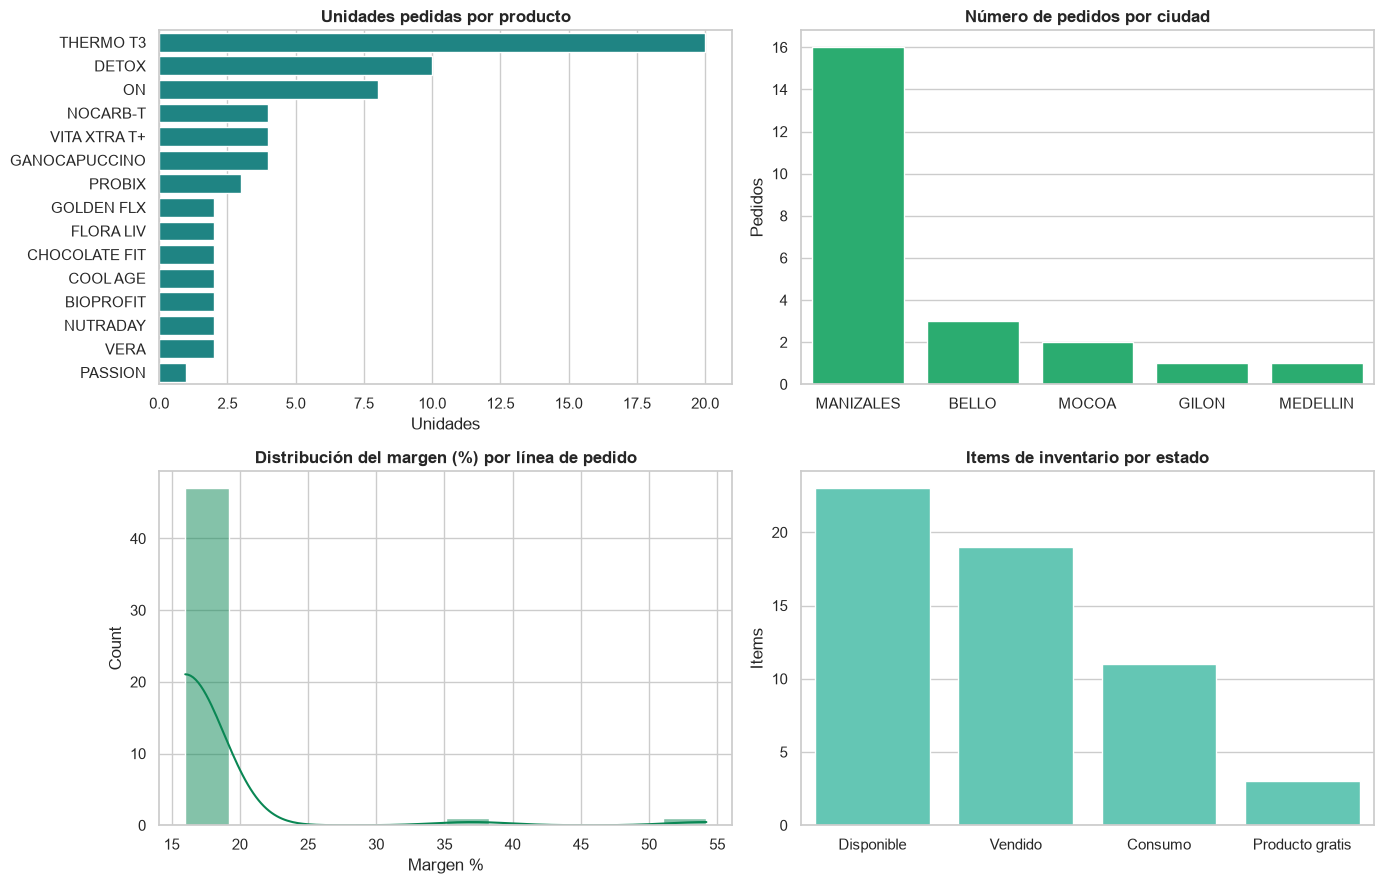

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Unidades por producto
top_prod = pedidos.groupby("producto")["cantidad"].sum().sort_values(ascending=False)
sns.barplot(x=top_prod.values, y=top_prod.index, ax=axes[0,0], color=PALETA[0])
axes[0,0].set_title("Unidades pedidas por producto"); axes[0,0].set_xlabel("Unidades"); axes[0,0].set_ylabel("")

# Pedidos por ciudad
ped_ciudad = pedidos.groupby("ciudad")["order_id"].nunique().sort_values(ascending=False)
sns.barplot(x=ped_ciudad.index, y=ped_ciudad.values, ax=axes[0,1], color=PALETA[1])
axes[0,1].set_title("Número de pedidos por ciudad"); axes[0,1].set_ylabel("Pedidos"); axes[0,1].set_xlabel("")

# Distribución del margen %
sns.histplot(pedidos["margen_pct"], bins=12, kde=True, ax=axes[1,0], color=PALETA[2])
axes[1,0].set_title("Distribución del margen (%) por línea de pedido"); axes[1,0].set_xlabel("Margen %")

# Inventario por estado
est = inventario["estado"].value_counts()
sns.barplot(x=est.index, y=est.values, ax=axes[1,1], color=PALETA[3])
axes[1,1].set_title("Items de inventario por estado"); axes[1,1].set_ylabel("Items"); axes[1,1].set_xlabel("")

plt.tight_layout(); plt.savefig(FIG/"univariado.png", dpi=110, bbox_inches="tight"); plt.show()

**Lecturas univariadas:**
- **THERMO T3** domina la demanda en unidades, seguido por DETOX y ON.
- La operación está **muy concentrada en una ciudad** (Manizales).
- El **margen por línea** se concentra alrededor del 16%, con algunos productos más rentables.
- En inventario conviven productos **vendidos, disponibles, de consumo propio y gratuitos**.

## 11. 🔀 Análisis bivariado

Relacionamos pares de variables para descubrir asociaciones.

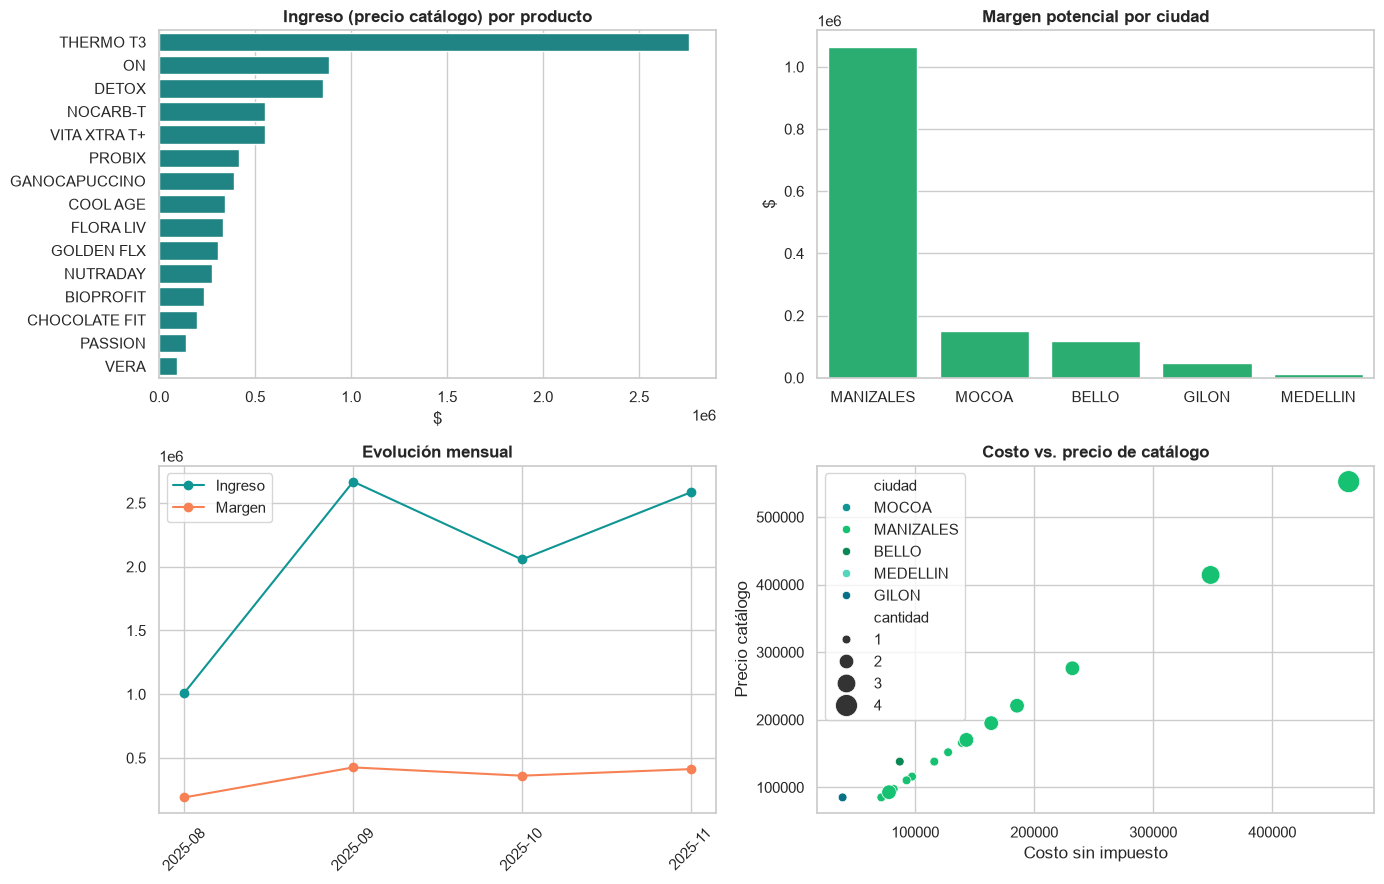

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Ingreso por producto
ing_prod = pedidos.groupby("producto")["precio_total_catalogo"].sum().sort_values(ascending=False)
sns.barplot(x=ing_prod.values, y=ing_prod.index, ax=axes[0,0], color=PALETA[0])
axes[0,0].set_title("Ingreso (precio catálogo) por producto"); axes[0,0].set_xlabel("$"); axes[0,0].set_ylabel("")

# Margen por ciudad
mar_ciudad = pedidos.groupby("ciudad")["margen_potencial"].sum().sort_values(ascending=False)
sns.barplot(x=mar_ciudad.index, y=mar_ciudad.values, ax=axes[0,1], color=PALETA[1])
axes[0,1].set_title("Margen potencial por ciudad"); axes[0,1].set_ylabel("$"); axes[0,1].set_xlabel("")

# Evolución mensual del ingreso y el margen
por_mes = pedidos.groupby("mes").agg(ingreso=("precio_total_catalogo","sum"),
                                     margen=("margen_potencial","sum")).reset_index()
axes[1,0].plot(por_mes["mes"], por_mes["ingreso"], marker="o", label="Ingreso", color=PALETA[0])
axes[1,0].plot(por_mes["mes"], por_mes["margen"], marker="o", label="Margen", color=PALETA[7])
axes[1,0].set_title("Evolución mensual"); axes[1,0].legend(); axes[1,0].tick_params(axis="x", rotation=45)

# Costo vs precio de catálogo (cada punto = una línea de pedido)
sns.scatterplot(data=pedidos, x="costo_sin_impuesto", y="precio_total_catalogo",
                hue="ciudad", size="cantidad", sizes=(40,250), ax=axes[1,1])
axes[1,1].set_title("Costo vs. precio de catálogo"); axes[1,1].set_xlabel("Costo sin impuesto"); axes[1,1].set_ylabel("Precio catálogo")

plt.tight_layout(); plt.savefig(FIG/"bivariado.png", dpi=110, bbox_inches="tight"); plt.show()

**Lecturas bivariadas:**
- El **ingreso** confirma a THERMO T3 como motor del negocio.
- **Manizales** aporta la gran mayoría del margen; las demás ciudades son marginales.
- La serie mensual muestra la **estacionalidad** y los meses pico.
- Existe una relación **lineal y estable** entre costo y precio de catálogo: el margen
  porcentual es relativamente constante entre productos.

## 12. 🧩 Análisis multivariado

Analizamos varias variables a la vez: correlaciones y la relación producto × ciudad.

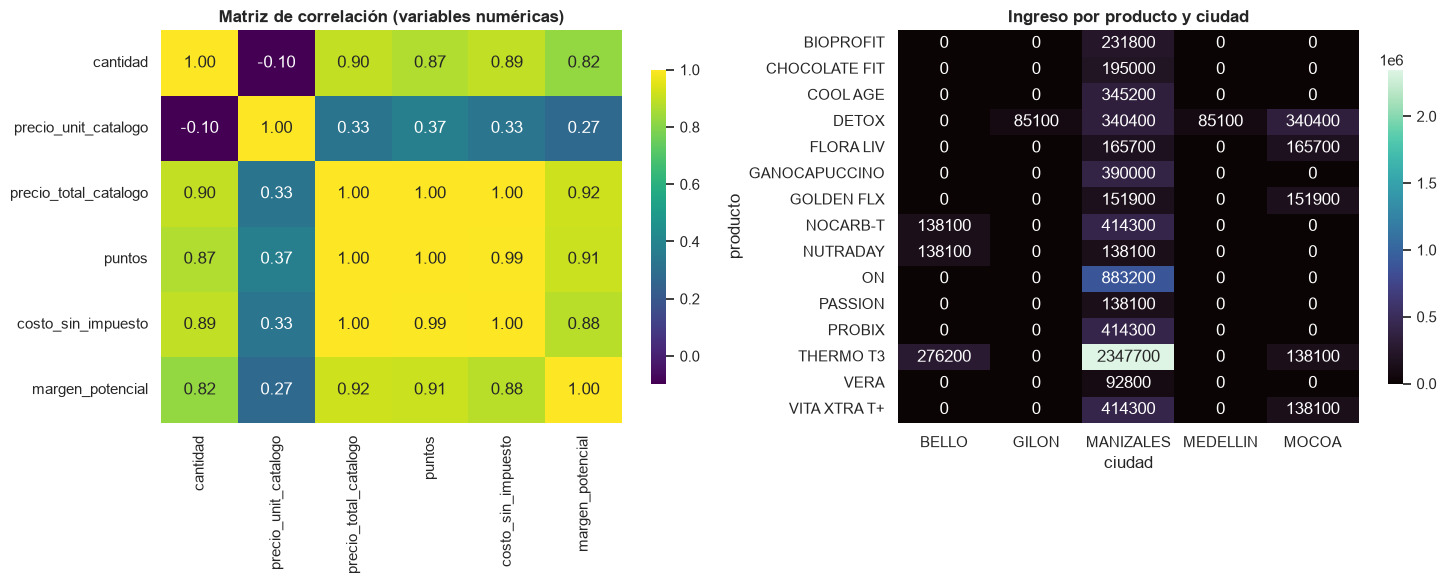

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Matriz de correlación
corr = pedidos[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", ax=axes[0], cbar_kws={"shrink":.8})
axes[0].set_title("Matriz de correlación (variables numéricas)")

# Mapa de calor producto x ciudad (ingreso)
pivot = pedidos.pivot_table(index="producto", columns="ciudad",
                            values="precio_total_catalogo", aggfunc="sum", fill_value=0)
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="mako", ax=axes[1], cbar_kws={"shrink":.8})
axes[1].set_title("Ingreso por producto y ciudad")

plt.tight_layout(); plt.savefig(FIG/"multivariado.png", dpi=110, bbox_inches="tight"); plt.show()

**Lecturas multivariadas:**
- Las variables monetarias (precio, costo, margen, puntos) están **fuertemente
  correlacionadas** entre sí: a mayor precio, mayor costo, margen y puntos.
- El mapa de calor **producto × ciudad** revela qué productos sostienen cada plaza y
  confirma la dependencia de Manizales como mercado principal.

## 13. ⏳ Inventario y riesgo de vencimiento

Uno de los hallazgos más accionables: **capital inmovilizado y productos por vencer.**

💰 Capital en inventario disponible: $2,423,300
📦 Items disponibles: 23


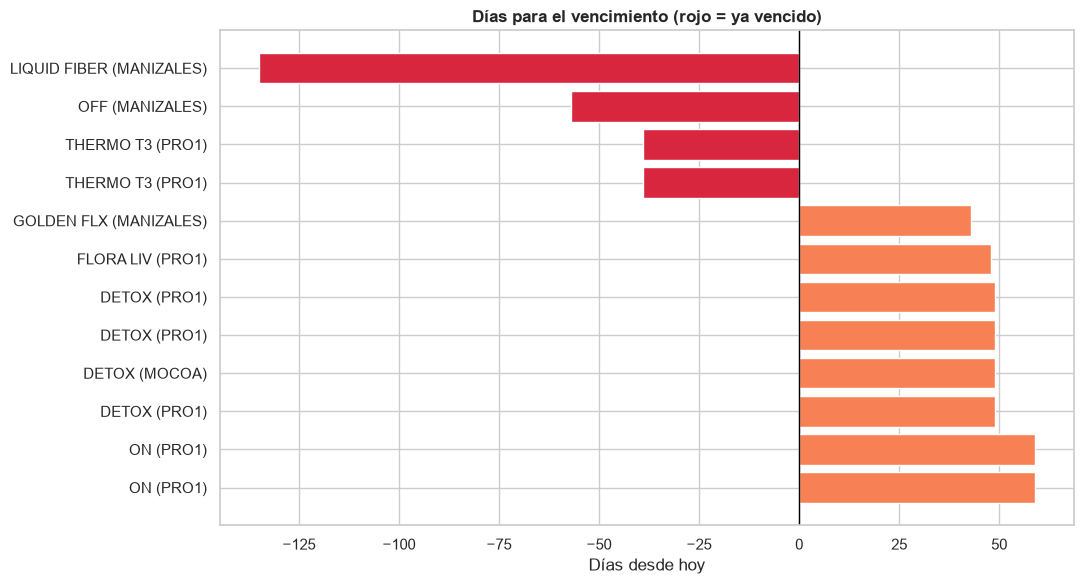


🚨 Productos disponibles YA VENCIDOS: 4  (capital: $538,500)


,producto,ubicacion,fecha_vencimiento,valor
10,LIQUID FIBER,MANIZALES,2026-01-29,110400.0
3,OFF,MANIZALES,2026-04-17,151900.0
46,THERMO T3,PRO1,2026-05-05,138100.0
47,THERMO T3,PRO1,2026-05-05,138100.0


In [14]:
disponible = inventario[inventario["estado"] == "Disponible"]
print(f"💰 Capital en inventario disponible: ${disponible['valor'].sum():,.0f}")
print(f"📦 Items disponibles: {len(disponible)}")

# Productos disponibles/gratuitos ordenados por cercanía al vencimiento
riesgo = inventario[inventario["estado"].isin(["Disponible","Producto gratis"])].copy()
riesgo = riesgo.dropna(subset=["fecha_vencimiento"]).sort_values("dias_para_vencer")

fig, ax = plt.subplots(figsize=(11, 6))
top = riesgo.head(12)
colores = ["#D7263D" if d < 0 else ("#F78154" if d < 90 else "#16C172") for d in top["dias_para_vencer"]]
ax.barh(range(len(top)), top["dias_para_vencer"], color=colores)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([f"{p} ({u})" for p,u in zip(top["producto"], top["ubicacion"])])
ax.axvline(0, color="black", lw=1)
ax.set_title("Días para el vencimiento (rojo = ya vencido)")
ax.set_xlabel("Días desde hoy"); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(FIG/"vencimientos.png", dpi=110, bbox_inches="tight"); plt.show()

vencidos = riesgo[riesgo["dias_para_vencer"] < 0]
print(f"\n🚨 Productos disponibles YA VENCIDOS: {len(vencidos)}  (capital: ${vencidos['valor'].sum():,.0f})")
display(vencidos[["producto","ubicacion","fecha_vencimiento","valor"]])

> 🚨 **Hallazgo crítico:** hay productos en stock que **ya se vencieron** sin haberse
> vendido, y otros próximos a vencer. Esto representa **pérdida directa de capital** y es
> la primera palanca de mejora del negocio: priorizar su venta o ajustar las compras.

## 14. 🧾 Composición de los ingresos del negocio

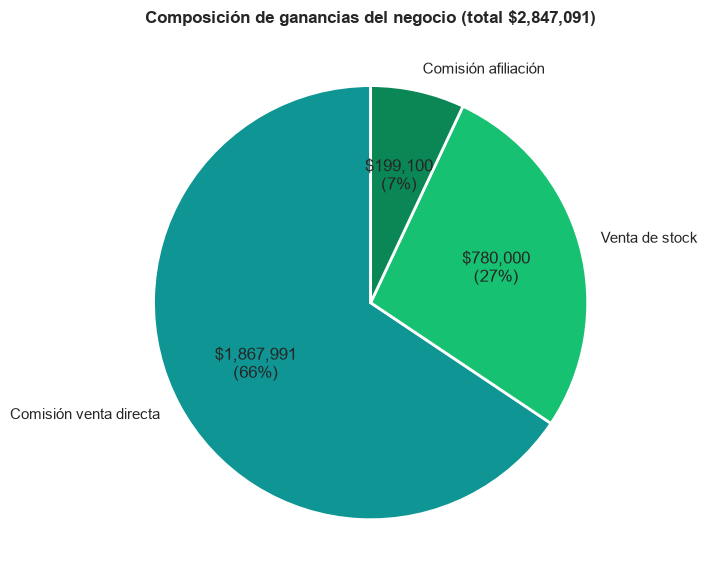

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
ing = ingresos.dropna()
ax.pie(ing["valor"], labels=ing["fuente"], autopct=lambda p: f"${p/100*ing['valor'].sum():,.0f}\n({p:.0f}%)",
       colors=PALETA[:3], startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
ax.set_title(f"Composición de ganancias del negocio (total ${ing['valor'].sum():,.0f})")
plt.tight_layout(); plt.savefig(FIG/"ingresos.png", dpi=110, bbox_inches="tight"); plt.show()

La **comisión por venta directa** es la principal fuente de ganancia, seguida por la
**venta de stock**. La **afiliación** aún aporta poco: una oportunidad de crecimiento.

## 15. 💾 Exportación de datos para el tablero (dashboard)

Guardamos los datos limpios y anonimizados (CSV) y un archivo **JSON** con los agregados
que alimentan el tablero interactivo publicado en GitHub Pages.

In [16]:
# CSVs procesados (anonimizados)
pedidos.to_csv(PROC/"pedidos_lineas.csv", index=False, encoding="utf-8-sig")
inventario.to_csv(PROC/"inventario.csv", index=False, encoding="utf-8-sig")
venta_directa.to_csv(PROC/"venta_directa.csv", index=False, encoding="utf-8-sig")
afiliaciones.to_csv(PROC/"afiliaciones.csv", index=False, encoding="utf-8-sig")

def tabla(df, cols): return df[cols].to_dict(orient="records")

prod = pedidos.groupby("producto").agg(
    unidades=("cantidad","sum"), ingreso=("precio_total_catalogo","sum"),
    costo=("costo_sin_impuesto","sum"), margen=("margen_potencial","sum"),
    pedidos=("order_id","nunique")).reset_index()
prod["margen_pct"] = (prod["margen"]/prod["ingreso"]*100).round(1)
prod = prod.sort_values("ingreso", ascending=False)

ciu = pedidos.groupby("ciudad").agg(
    pedidos=("order_id","nunique"), unidades=("cantidad","sum"),
    ingreso=("precio_total_catalogo","sum"), margen=("margen_potencial","sum")).reset_index().sort_values("ingreso", ascending=False)

por_mes = pedidos.groupby("mes").agg(ingreso=("precio_total_catalogo","sum"),
    margen=("margen_potencial","sum"), unidades=("cantidad","sum"),
    pedidos=("order_id","nunique")).reset_index().sort_values("mes")

inv_estado = inventario.groupby("estado").agg(n=("producto","count"), valor=("valor","sum")).reset_index().sort_values("valor", ascending=False)
inv_ubic = inventario.groupby("ubicacion").agg(n=("producto","count"), valor=("valor","sum")).reset_index()
disp = inventario[inventario["estado"]=="Disponible"]
pv = inventario[inventario["estado"].isin(["Disponible","Producto gratis"])].dropna(subset=["fecha_vencimiento"]).sort_values("dias_para_vencer").head(10).copy()
pv["fecha_vencimiento"] = pv["fecha_vencimiento"].dt.strftime("%Y-%m-%d")

dashboard = {
  "generado": HOY.strftime("%Y-%m-%d"),
  "kpis": {
    "pedidos": int(pedidos["order_id"].nunique()),
    "unidades": int(pedidos["cantidad"].sum()),
    "productos_distintos": int(pedidos["producto"].nunique()),
    "ciudades": int(pedidos["ciudad"].nunique()),
    "ingreso_catalogo": float(pedidos["precio_total_catalogo"].sum()),
    "costo_total": float(pedidos["costo_sin_impuesto"].sum()),
    "margen_total": float(pedidos["margen_potencial"].sum()),
    "margen_pct_global": round(float(pedidos["margen_potencial"].sum()/pedidos["precio_total_catalogo"].sum()*100),1),
    "ticket_promedio": round(float(pedidos.groupby("order_id")["precio_total_catalogo"].sum().mean()),0),
    "items_inventario": int(inventario["cantidad"].sum()),
    "capital_disponible": float(disp["valor"].sum()),
    "ganancia_total_negocio": float(ingresos["valor"].dropna().sum()),
  },
  "productos": {"tabla": tabla(prod, ["producto","unidades","pedidos","ingreso","costo","margen","margen_pct"])},
  "ciudades": tabla(ciu, ["ciudad","pedidos","unidades","ingreso","margen"]),
  "tiempo": {"por_mes": tabla(por_mes, ["mes","ingreso","margen","unidades","pedidos"])},
  "inventario": {
    "por_estado": tabla(inv_estado, ["estado","n","valor"]),
    "por_ubicacion": tabla(inv_ubic, ["ubicacion","n","valor"]),
    "por_vencer": tabla(pv, ["producto","ubicacion","fecha_vencimiento","dias_para_vencer","valor"]),
    "capital_disponible": float(disp["valor"].sum()),
  },
  "ingresos": tabla(ingresos.dropna(), ["fuente","valor"]),
  "venta_directa": {
    "total": float(venta_directa["total_recibido"].sum()),
    "transacciones": int(venta_directa.shape[0]),
  },
  "afiliaciones": {
    "total": int(afiliaciones.shape[0]),
    "comision_total": float(a_numero(afiliaciones["comision"]).sum()),
    "puntos_total": int(a_numero(afiliaciones["puntos"]).sum()),
  },
}
with open(DOCS/"dashboard.json", "w", encoding="utf-8") as f:
    json.dump(dashboard, f, ensure_ascii=False, indent=2)
print("✅ Datos exportados a data/processed/ y docs/data/dashboard.json")

✅ Datos exportados a data/processed/ y docs/data/dashboard.json


## 16. ✅ Conclusiones y recomendaciones de negocio

### Hallazgos principales
1. 🏆 **Producto estrella:** *THERMO T3* lidera demanda, ingreso y presencia en pedidos.
   El portafolio de mayor rotación lo completan *DETOX*, *ON* y *NOCARB-T*.
2. 📍 **Dependencia geográfica:** *Manizales* concentra cerca del 80% de los ingresos.
   Hay alta exposición a una sola plaza.
3. 💵 **Margen estable (~16–20%)** entre productos: la rentabilidad se gana por **volumen y
   rotación**, no por diferencias de margen entre productos.
4. 🚨 **Capital en riesgo:** hay un monto importante inmovilizado en inventario y **productos
   ya vencidos** sin vender → pérdida directa.
5. 🧾 **Ingresos concentrados** en la comisión por venta directa; la **afiliación** está
   subutilizada.

### Recomendaciones accionables
- 📦 **Gestión de inventario por vencimiento (FEFO):** priorizar la venta de lo próximo a
  vencer y ajustar las compras a la rotación real de cada producto.
- 🎯 **Doblar la apuesta por los productos y la ciudad ganadores**, pero **diversificar
  geográficamente** para reducir la dependencia de Manizales.
- 🤝 **Impulsar la afiliación** como fuente de ingreso recurrente y escalable.
- 📊 **Institucionalizar el dato:** mantener el registro limpio para, en una fase siguiente,
  construir un **modelo predictivo de demanda** (CRISP-DM fases 4–6).

> Este EDA cumple las fases 1–3 del ciclo de vida de ML y deja la base lista —datos limpios,
> anonimizados y comprendidos— para futuras fases de modelado.
